# Data Augmentation Techniques: Geometric and Color Transformations

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates two common data augmentation techniques: **geometric transformations** (resizing, flipping, rotation, cropping) and **color transformations** (brightness, contrast, saturation, hue). Data augmentation is used to artificially increase the size and diversity of training datasets, improving model generalisation.

**Key Concepts Covered:**
- Geometric transformations: resizing, horizontal/vertical flips, rotation, cropping.
- Color transformations: brightness, contrast, saturation, hue adjustment.
- Using `skimage` and `PIL` for augmentation – no external deep learning framework required.

**Key Techniques & Libraries:**
- `skimage` – image loading and transformations.
- `matplotlib` – visualisation.
- `PIL` (Pillow) – image handling and color adjustments.

**Objective:**
To understand how data augmentation works and how to apply it to images to increase dataset variability and improve model robustness.

In [3]:
import skimage.io as skio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance
from skimage import data, transform, util
import random

print("All imports successful.")

All imports successful.


## 1. Load Sample Image

We load a sample color image from `scikit-image` (the 'astronaut' image). This avoids the need for external files.

Original image shape: (512, 512, 3)


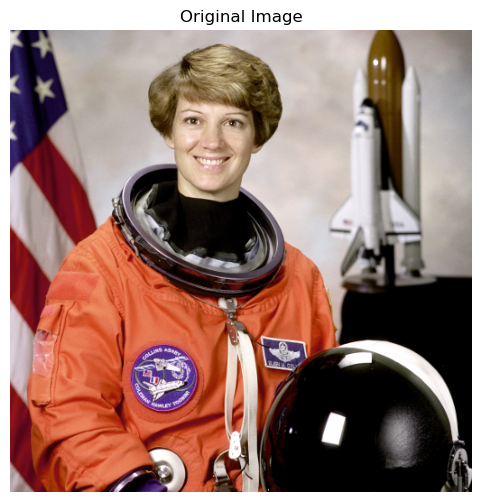

In [4]:
def show_image(image, title=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

# Use a built-in sample image (color)
image = data.astronaut()  # 512x512x3 RGB image
print(f"Original image shape: {image.shape}")

show_image(image, "Original Image")

## 2. Geometric Transformations

We apply several geometric transformations using `skimage.transform` and `PIL`.

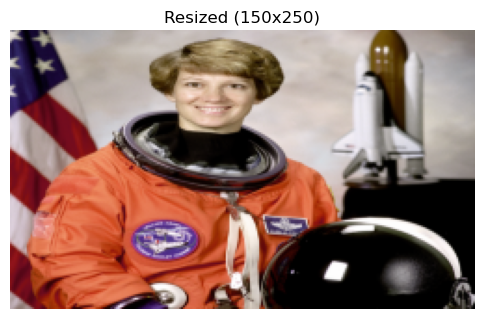

In [5]:
# Resize using skimage
image_resized = transform.resize(image, (150, 250), anti_aliasing=True)
show_image(image_resized, "Resized (150x250)")

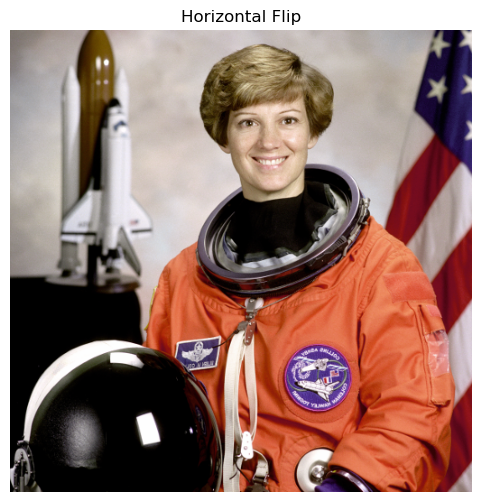

In [6]:
# Horizontal flip using skimage
image_hflip = np.fliplr(image)
show_image(image_hflip, "Horizontal Flip")

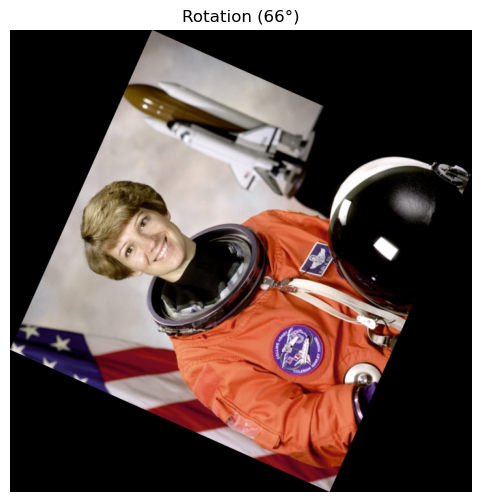

In [7]:
# Rotation using skimage
image_rotated = transform.rotate(image, angle=66, resize=True)
show_image(image_rotated, "Rotation (66°)")

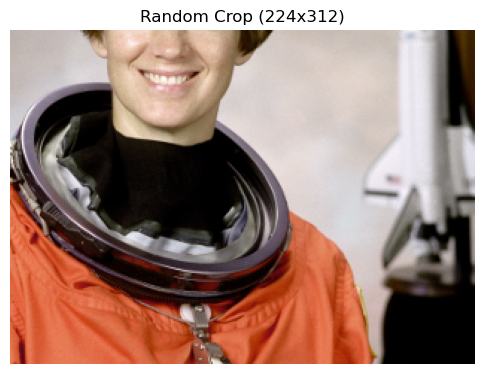

In [8]:
# Random crop using skimage
def random_crop(img, crop_size=(224, 312)):
    h, w = img.shape[:2]
    top = random.randint(0, h - crop_size[0])
    left = random.randint(0, w - crop_size[1])
    return img[top:top+crop_size[0], left:left+crop_size[1]]

image_cropped = random_crop(image, (224, 312))
show_image(image_cropped, "Random Crop (224x312)")

## 3. Color Transformations

We apply color augmentation using `PIL.ImageEnhance` for brightness, contrast, saturation, and hue (via manual HSV conversion).

In [9]:
def adjust_brightness(img, factor):
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    enhancer = ImageEnhance.Brightness(pil_img)
    return np.array(enhancer.enhance(factor)) / 255.0

def adjust_contrast(img, factor):
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    enhancer = ImageEnhance.Contrast(pil_img)
    return np.array(enhancer.enhance(factor)) / 255.0

def adjust_saturation(img, factor):
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    enhancer = ImageEnhance.Color(pil_img)
    return np.array(enhancer.enhance(factor)) / 255.0

def adjust_hue(img, hue_shift):
    from skimage.color import rgb2hsv, hsv2rgb
    hsv = rgb2hsv(img)
    hsv[..., 0] = (hsv[..., 0] + hue_shift) % 1.0
    return hsv2rgb(hsv)

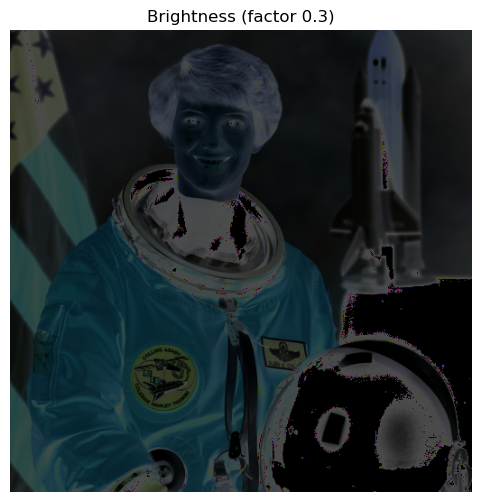

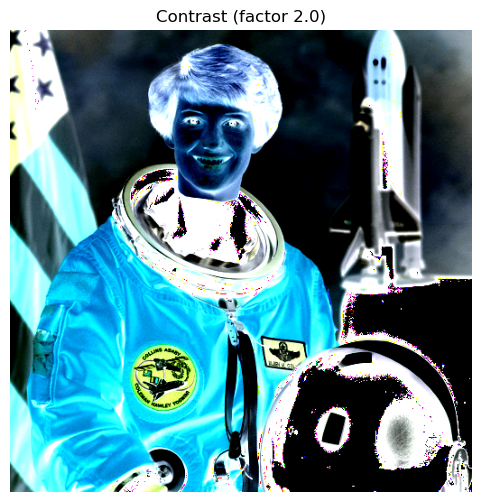

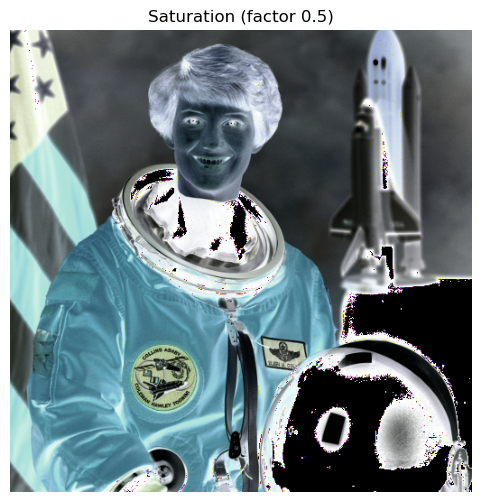

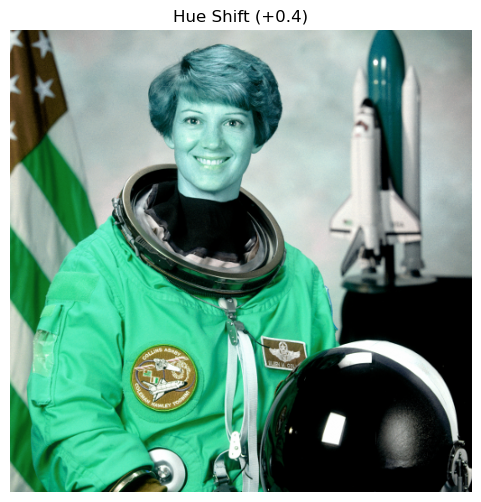

In [10]:
# Brightness
image_bright = adjust_brightness(image, factor=0.3)
show_image(image_bright, "Brightness (factor 0.3)")

# Contrast
image_contrast = adjust_contrast(image, factor=2.0)
show_image(image_contrast, "Contrast (factor 2.0)")

# Saturation
image_saturated = adjust_saturation(image, factor=0.5)
show_image(image_saturated, "Saturation (factor 0.5)")

# Hue
image_hue = adjust_hue(image, hue_shift=0.4)
show_image(image_hue, "Hue Shift (+0.4)")

## 4. Combined Transformations

In practice, we often compose multiple transformations into a single pipeline. For example, we can apply a random crop, horizontal flip, and color jitter together.

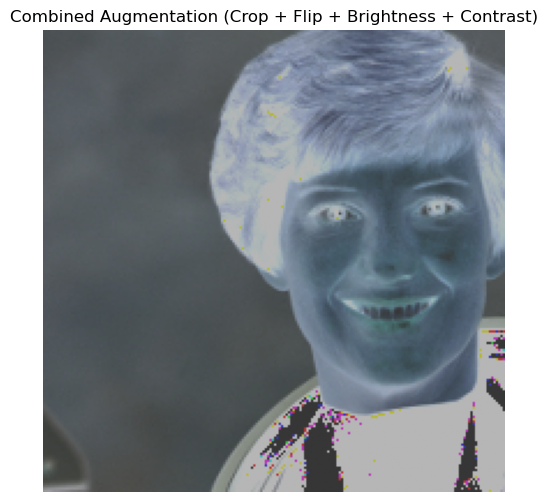

In [11]:
def combined_augmentation(img):
    # Random crop to 200x200
    h, w = img.shape[:2]
    crop_size = (200, 200)
    top = random.randint(0, h - crop_size[0])
    left = random.randint(0, w - crop_size[1])
    cropped = img[top:top+crop_size[0], left:left+crop_size[1]]
    
    # Random horizontal flip
    if random.random() > 0.5:
        cropped = np.fliplr(cropped)
    
    # Random brightness and contrast
    brightness_factor = random.uniform(0.5, 1.5)
    contrast_factor = random.uniform(0.5, 1.5)
    cropped = adjust_brightness(cropped, brightness_factor)
    cropped = adjust_contrast(cropped, contrast_factor)
    
    return cropped

# Apply combined augmentation
augmented = combined_augmentation(image)
show_image(augmented, "Combined Augmentation (Crop + Flip + Brightness + Contrast)")

## Summary and Next Steps

**Accomplished:**
- Loaded a sample color image.
- Applied geometric transformations: resize, horizontal flip, vertical flip, rotation, crop.
- Applied color transformations: brightness, contrast, saturation, hue adjustments.
- Demonstrated a combined augmentation pipeline using skimage and PIL.

**Key Insights:**
- Data augmentation is a powerful technique to increase dataset size and variability without collecting new data.
- Geometric transformations help the model become invariant to position, orientation, and scale.
- Color transformations help the model become robust to lighting and color variations.
- Augmentations should be chosen carefully to reflect realistic variations in the target domain.
- No external deep learning frameworks are required; `skimage` and `PIL` provide all necessary tools.

**Suggested Next Steps:**
1. **Apply augmentations to a dataset** – integrate these transforms into a training pipeline (e.g., using `torchvision` or `tensorflow`).
2. **Experiment with different augmentation parameters** – vary degrees, probabilities, and magnitudes.
3. **Compare model performance** – train a model with and without augmentation to see the difference.
4. **Visualise augmentations** – display multiple augmented versions of the same image side‑by‑side.
5. **Use more advanced augmentations** – e.g., cutout, mixup, or autoaugment.

**Reflection:**
This notebook provides a practical introduction to data augmentation techniques commonly used in computer vision. By applying geometric and color transformations, we can create diverse training samples that help neural networks generalise better. The use of `skimage` and `PIL` makes the notebook lightweight and independent of deep learning frameworks, making it easy to understand the core concepts.